# Exploratory Data Analysis (EDA)
## Dataset: application_train

**Author:** Oknardo Tulung  
**LinkedIn:** https://www.linkedin.com/in/oknardo-tulung/ 
**GitHub:** https://github.com/oknardo/Home_Credit_Scorecard_Model

---

## 📌 Project Overview
This project focuses on performing a comprehensive Exploratory Data Analysis (EDA) on the `application_train` dataset from the Home Credit risk modeling case. The goal is to understand the underlying patterns, data quality, and key drivers related to loan default behavior.

---

## 🎯 Objectives
- Understand the structure and characteristics of the dataset  
- Identify data quality issues (missing values, outliers, inconsistencies)  
- Analyze the distribution of key variables  
- Explore relationships between features and the target variable (loan default)  
- Generate initial insights to support feature engineering and modeling  

---

## 🔍 Analysis Scope
The analysis includes:
- Missing Value Analysis
- Univariate analysis (distribution of individual variables)  
- Bivariate analysis (relationship with TARGET)  
- Identification of class imbalance  
- Detection of anomalies and outliers  
- Initial business-driven interpretation of features  

---

## 🧠 Key Questions
- What factors differentiate default vs non-default customers?  
- How is income related to credit amount and repayment behavior?  
- Are there strong predictors within external scores (EXT_SOURCE)?  
- What patterns exist in demographic and financial features?  

---

## 🛠 Tools & Libraries
- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  

---

## 📊 Output
The output of this EDA will serve as:
- A foundation for feature engineering  
- Input for credit scoring models  
- Business insights for risk assessment  

# Importing Library

In [3]:
# Installation Library
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Hide Warning
import warnings
warnings.filterwarnings('ignore')

# Importing Library
import pandas as pd
# Setting Pandas Row Display Max
pd.set_option('display.max_rows', None)

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Importing Dataset

In [5]:
# Dataset application_train
application_train = r'D:\Python\Projects\Project Scorecard Model Home Credit Indonesia\home-credit-default-risk\application_train.csv'
df_app_train = pd.read_csv(application_train)

# 1. About Dataset

The dataset consists of **307,511 observations** and **122 features**, representing individual loan application data. Each row corresponds to a single applicant, including financial, demographic, and supporting information.

The features can be grouped into several categories:
- **Target variable**: `TARGET`, indicating the default status  
- **Numerical features**: financial, temporal, and other quantitative variables  
- **Categorical features**: such as occupation type, family status, and contract type  
- **Binary indicators**: flags related to asset ownership and document submission  

Additionally, the dataset includes features with suffixes `_AVG`, `_MEDI`, and `_MODE`, which represent **aggregated characteristics of the applicant’s living environment**, such as building conditions and facilities.

In [6]:
df_app_train.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 122 columns):
 #    Column                        Dtype  
---   ------                        -----  
 0    SK_ID_CURR                    int64  
 1    TARGET                        int64  
 2    NAME_CONTRACT_TYPE            str    
 3    CODE_GENDER                   str    
 4    FLAG_OWN_CAR                  str    
 5    FLAG_OWN_REALTY               str    
 6    CNT_CHILDREN                  int64  
 7    AMT_INCOME_TOTAL              float64
 8    AMT_CREDIT                    float64
 9    AMT_ANNUITY                   float64
 10   AMT_GOODS_PRICE               float64
 11   NAME_TYPE_SUITE               str    
 12   NAME_INCOME_TYPE              str    
 13   NAME_EDUCATION_TYPE           str    
 14   NAME_FAMILY_STATUS            str    
 15   NAME_HOUSING_TYPE             str    
 16   REGION_POPULATION_RELATIVE    float64
 17   DAYS_BIRTH                    int64  
 18   DAYS_EMPLOYED

In [7]:
df_app_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

# 2. Target Distribution
The target distribution shows that the majority of applicants **do not default (non-default)**.

- Total non-default (`TARGET = 0`): 282,686 (~91.9%)
- Total default (`TARGET = 1`): 24,825 (~8.1%)

This indicates that the dataset is **imbalanced**, where the number of default cases is significantly lower than non-default cases. This condition should be considered during the modeling stage, particularly in selecting appropriate evaluation metrics and handling class imbalance.

In [8]:
df_app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

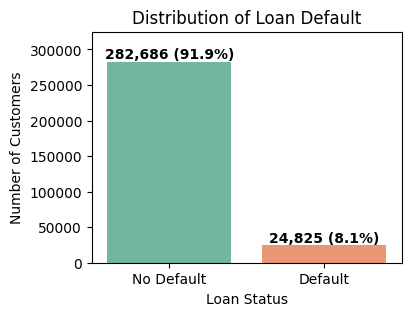

In [9]:
# Prepare data
target_df = (
    df_app_train['TARGET']
    .value_counts()
    .rename_axis('Target')
    .reset_index(name='Count')
    .assign(
        Percentage=lambda x: x['Count'] / x['Count'].sum() * 100,
        Target=lambda x: x['Target'].map({0: 'No Default', 1: 'Default'})
    )
)

# Plot
plt.figure(figsize=(4, 3))
ax = sns.barplot(
    data=target_df, x='Target', y='Count',
    hue='Target', palette='Set2', legend=False
)

plt.ylim(0, 325000)
plt.title('Distribution of Loan Default')
plt.xlabel('Loan Status')
plt.ylabel('Number of Customers')

# Add count and percentage labels on each bar
for i, row in target_df.iterrows():
    ax.text(
        i, row['Count'],
        f"{row['Count']:,} ({row['Percentage']:.1f}%)",
        ha='center', va='bottom', fontweight='bold'
    )

plt.show()

# 3. Missing Value Analysis

The missing value analysis is conducted to assess data quality and identify potential information contained within missing data.

The approach includes:
- **Measuring** the count and percentage of missing values for each feature  
- **Grouping** features based on their level of missingness  
- **Evaluating** the relationship between missing values and the *default rate*  

The results of this analysis serve as recommendations for the data handling stage, including:
- **Imputing values** for features with moderate missingness  
- **Creating missing indicators** to capture potential risk patterns associated with missing data
- **Considering removal** of features with very high missing rates and weak predictive signal

## 3.1 Missing Values Count
This section calculates the count and percentage of missing values for each feature,
along with its data type.

In [10]:
# Check missing values: count, percentage, and data type per feature
missing_df = (
    df_app_train.isnull()
    # sum = total missing, mean = proportion missing
    .agg(['sum', 'mean'])
    .T
    # make feature names a column
    .reset_index()
    .rename(columns={
        'index': 'Feature',
        'sum': 'Missing_Count',
        'mean': 'Missing_Percentage'
    })
    .assign(
        # Convert proportion to percentage
        Missing_Percentage=lambda x: (x['Missing_Percentage'] * 100).round(2),
        # Add data type per feature
        Data_Type=lambda x: x['Feature'].map(df_app_train.dtypes)
    )
    # Sort
    .sort_values(by='Missing_Percentage', ascending=False)
)

missing_df.head()

,Feature,Missing_Count,Missing_Percentage,Data_Type
48,COMMONAREA_AVG,214865.0,69.87,float64
62,COMMONAREA_MODE,214865.0,69.87,float64
76,COMMONAREA_MEDI,214865.0,69.87,float64
84,NONLIVINGAPARTMENTS_MEDI,213514.0,69.43,float64
70,NONLIVINGAPARTMENTS_MODE,213514.0,69.43,float64


## 3.2 Default Rate to Missing Features
This section examines whether missing values carry predictive signal by comparing
the default rate between rows where data is present versus missing.

In [11]:
# Get all features with missing values
all_missing_features = missing_df.loc[
    missing_df['Missing_Percentage'] > 0, 'Feature'
].tolist()

# Create a lookup dictionary from missing_df for O(1) access per feature
missing_pct_lookup = missing_df.set_index('Feature')['Missing_Percentage'].to_dict()

# Build a summary DataFrame for all features that have missing values
missing_default_rate = pd.DataFrame([
    {
        'Feature': col,
        'Missing_Percentage (%)': missing_pct_lookup[col],
        'Default Rate (Not Missing) (%)': df_app_train.loc[df_app_train[col].notna(), 'TARGET'].mean() * 100,
        'Default Rate (Missing) (%)': df_app_train.loc[df_app_train[col].isna(), 'TARGET'].mean() * 100,
    }
    for col in all_missing_features
]).set_index('Feature').round(2)

missing_default_rate

,Missing_Percentage (%),Default Rate (Not Missing) (%),Default Rate (Missing) (%)
Feature,,,
COMMONAREA_AVG,69.87,6.91,8.57
COMMONAREA_MODE,69.87,6.91,8.57
COMMONAREA_MEDI,69.87,6.91,8.57
NONLIVINGAPARTMENTS_MEDI,69.43,6.91,8.58
NONLIVINGAPARTMENTS_MODE,69.43,6.91,8.58
NONLIVINGAPARTMENTS_AVG,69.43,6.91,8.58
FONDKAPREMONT_MODE,68.39,6.89,8.62
LIVINGAPARTMENTS_AVG,68.35,6.89,8.62
LIVINGAPARTMENTS_MEDI,68.35,6.89,8.62


In [12]:
df_app_train['OWN_CAR_AGE'].isnull().sum()

np.int64(202929)

In [13]:
df_app_train['FLAG_OWN_CAR'].value_counts()

FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

### Key Findings & Handling Strategy

Most missing features show **higher default rate when missing**, meaning missingness itself
is a risk signal worth preserving. A few features show the opposite pattern where missing rows
have **lower default rate**, but remain informative nonetheless.

**Missing Indicator** is a new binary column (0/1) to flag whether a value was originally missing,
before the NaN is filled with an imputed value. For building features with **more than 60% missing**,
consider dropping the original feature and keeping only the `_MISSING` indicator to avoid noise.

**Numerical Features**
- **> 50% missing**: Building features (`APARTMENTS_*`, `FLOORS*`, `LIVINGAREA_*`, `LANDAREA_*`, etc.) — Missing Indicator + Median Impute, or drop original and keep indicator only.
- **10–50% missing**: `EXT_SOURCE_1`, `EXT_SOURCE_3`, `AMT_REQ_CREDIT_BUREAU_*` — Missing Indicator + Median Impute.
- **< 1% missing**: `EXT_SOURCE_2`, `AMT_GOODS_PRICE` — Simple Median Impute, no indicator needed.

> ⚠️ `OWN_CAR_AGE` missing likely means the applicant has no car. Impute with `0` or derive a `HAS_CAR` flag from `FLAG_OWN_CAR`.

**Categorical Features**
- **> 50% missing**: `FONDKAPREMONT_MODE`, `WALLSMATERIAL_MODE`, `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE` — Missing Indicator + Mode/`'Unknown'` Impute.
- **10–50% missing**: `OCCUPATION_TYPE` — Missing Indicator + Mode/`'Unknown'` Impute.
- **< 1% missing**: `NAME_TYPE_SUITE` — Simple Mode Impute, no indicator needed.

**Note on Building Features (`_AVG`, `_MODE`, `_MEDI`):** Features such as `APARTMENTS_AVG`,
`FLOORSMAX_MODE`, `LIVINGAREA_MEDI` are normalized statistical aggregations of the same property.
Since they are highly correlated, consider retaining only `_AVG` per group or applying **PCA**.

---

# 4. Numerical Features Analysis


## 4.1 Univariate Analysis

Univariate analysis examines each numerical feature independently to understand
its distribution, central tendency, and spread. This serves as the foundation
before exploring relationships between features and the target variable.

The approach includes:
- **Describing** each feature through summary statistics (mean, median, std, min, max)
- **Identifying** potential anomalies, skewness, and extreme values

### 4.1.1 Statistical Descriptive

In [14]:
df_app_train.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,1.000020e+05,189145.500000,278202.000000,367142.500000,4.562550e+05
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_CREDIT,307511.0,599025.999706,402490.776996,4.500000e+04,270000.000000,513531.000000,808650.000000,4.050000e+06
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-1.791200e+04,-2760.000000,-1213.000000,-289.000000,3.652430e+05


In [15]:
df_app_train['FLAG_MOBIL'].value_counts()

FLAG_MOBIL
1    307510
0         1
Name: count, dtype: int64

In [16]:
df_app_train['FLAG_CONT_MOBILE'].value_counts()

FLAG_CONT_MOBILE
1    306937
0       574
Name: count, dtype: int64

In [17]:
df_app_train['DAYS_BIRTH'].value_counts().head()

DAYS_BIRTH
-13749    43
-13481    42
-18248    41
-10020    41
-10292    40
Name: count, dtype: int64

In [18]:
df_app_train['DAYS_REGISTRATION'].value_counts().head()

DAYS_REGISTRATION
-1.0    113
-7.0     98
-6.0     96
-4.0     92
-2.0     92
Name: count, dtype: int64

In [19]:
df_app_train['CNT_CHILDREN'].value_counts()

CNT_CHILDREN
0     215371
1      61119
2      26749
3       3717
4        429
5         84
6         21
7          7
14         3
8          2
9          2
12         2
10         2
19         2
11         1
Name: count, dtype: int64

In [20]:
df_app_train['CNT_FAM_MEMBERS'].value_counts()

CNT_FAM_MEMBERS
2.0     158357
1.0      67847
3.0      52601
4.0      24697
5.0       3478
6.0        408
7.0         81
8.0         20
9.0          6
10.0         3
14.0         2
12.0         2
20.0         2
16.0         2
13.0         1
15.0         1
11.0         1
Name: count, dtype: int64

In [21]:
df_app_train['AMT_REQ_CREDIT_BUREAU_YEAR'].value_counts().tail()

AMT_REQ_CREDIT_BUREAU_YEAR
25.0    1
23.0    1
22.0    1
21.0    1
20.0    1
Name: count, dtype: int64

#### Key Findings

**Target & Class Imbalance**
Mean of `TARGET` is 0.08, only **8% of applicants defaulted**, confirming a heavily imbalanced dataset.
This must be addressed during modeling (e.g. oversampling, class weighting).

**Anomalies Detected**
- `DAYS_EMPLOYED` max = **365,243**, outlier/encoding error, likely flags pensioners or unemployed.
- `AMT_INCOME_TOTAL` max = **117,000,000**, extreme outlier, needs capping.
- `CNT_CHILDREN` max = 19 and `CNT_FAM_MEMBERS` max = 20, suspicious values worth investigating.

**Skewed Distributions**
- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` are right skewed, may require log transformation.
- `OBS/DEF_CNT_SOCIAL_CIRCLE` has median = 0 with max 348, heavily right-skewed.
- `AMT_REQ_CREDIT_BUREAU_*` has median = 0, majority of applicants had no enquiries.

**Near-Zero Variance - Consider Dropping**
- `FLAG_MOBIL` (mean = 0.9999) and `FLAG_CONT_MOBILE` (mean = 0.998) are almost constant.

**Days Features (Negative Values)**
`DAYS_BIRTH`, `DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE` are negative
by design. Consider converting to absolute values or age in years for interpretability.

**External Credit Scores (`EXT_SOURCE_1/2/3`)**
Normalized between 0 and 1 with mean ~0.50, well-distributed and likely strong predictors.

**Building Features (`_AVG`, `_MODE`, `_MEDI`)**
Nearly identical statistics across all three suffix variants, confirming high redundancy.
Retaining only `_AVG` per property group is sufficient.

**Features for Further Analysis**
- `AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY` to check distribution shape and skewness
- `DAYS_BIRTH`, `DAYS_EMPLOYED` to check distribution and confirm anomaly on `DAYS_EMPLOYED`
- `EXT_SOURCE_1/2/3` to check distribution as key predictive features
- `DAYS_EMPLOYED`, `OBS/DEF_30_CNT_SOCIAL_CIRCLE` to check outlier severity

---

### 4.1.2 Distribution Plot
Distribution plots are used to examine the shape of each numerical feature -
whether it is normally distributed, right-skewed, or contains anomalies.
Features with high skewness may require log transformation during preprocessing.


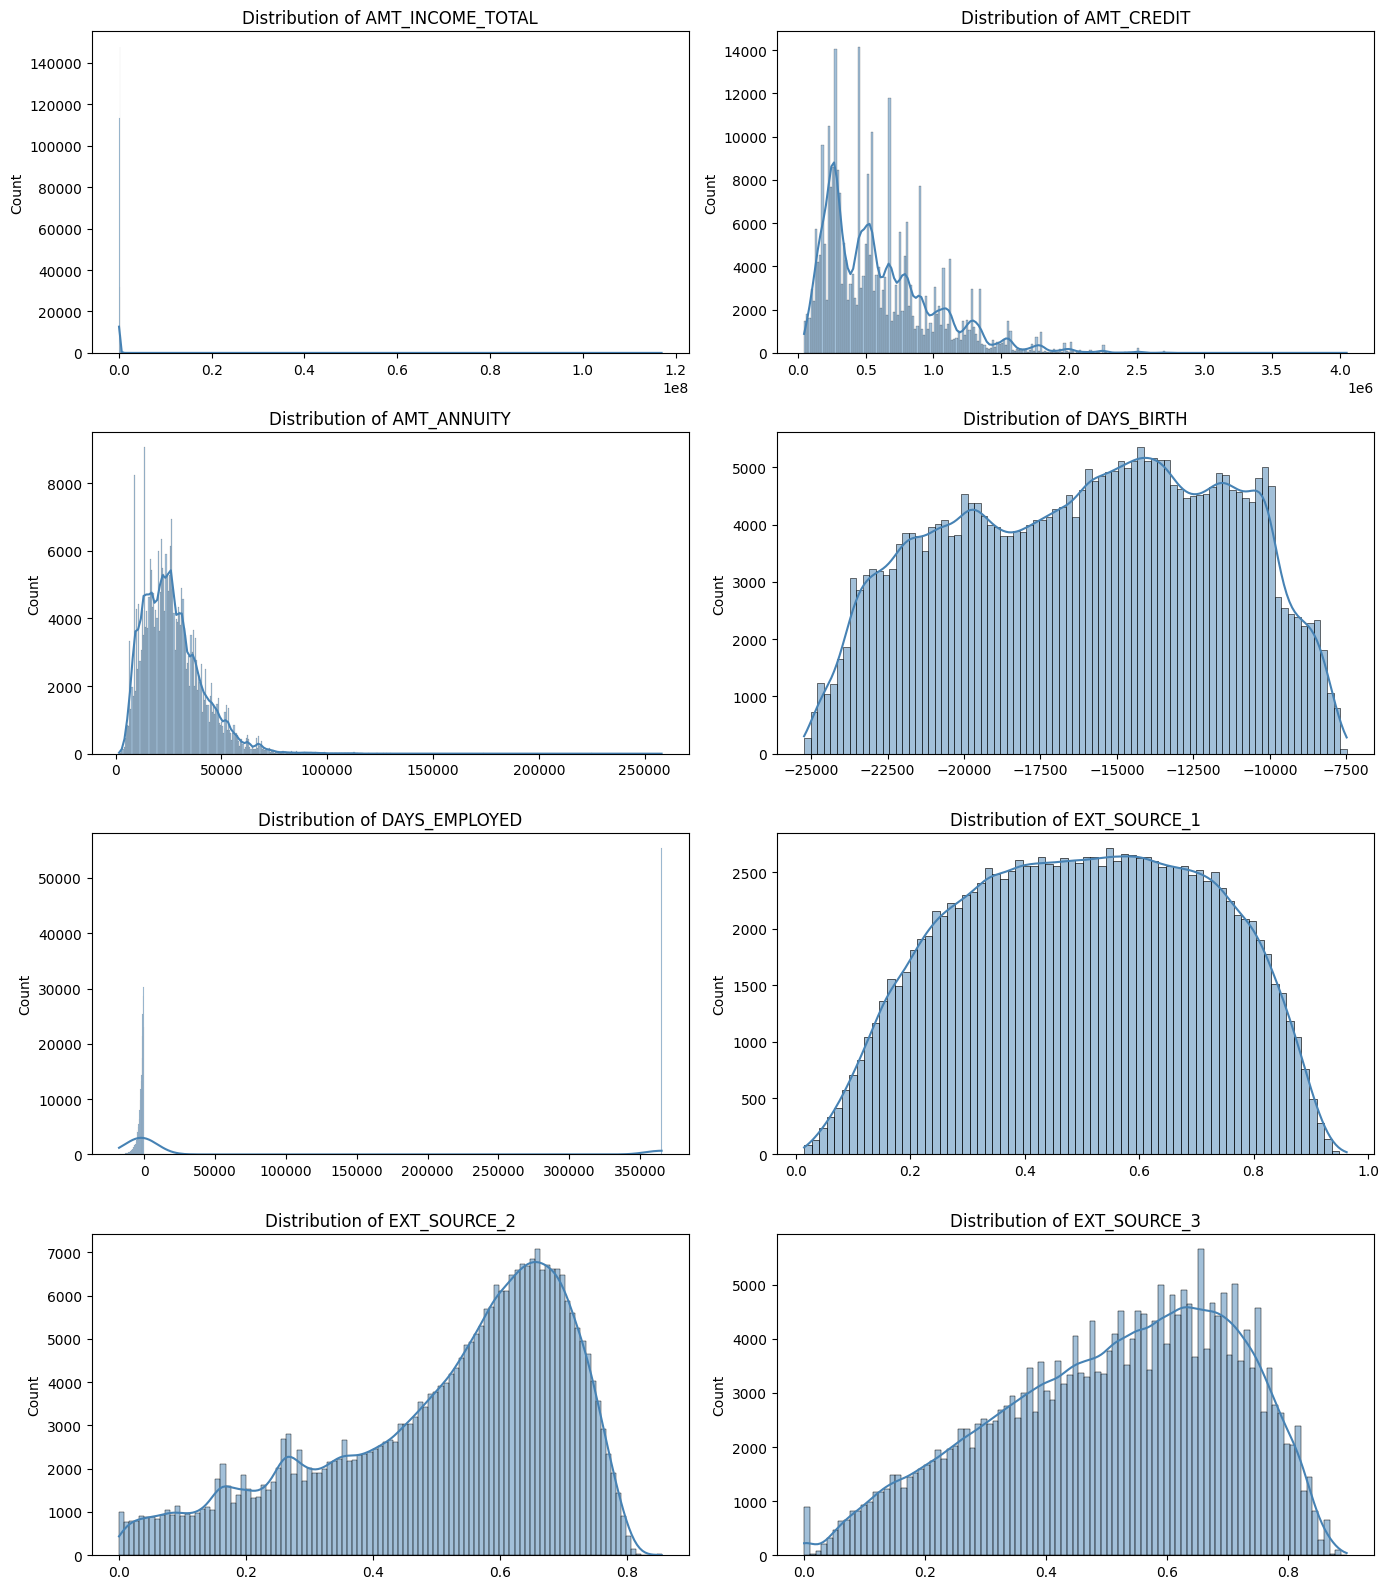

In [22]:
# Select key numerical features for distribution analysis
num_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# 4 Grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # Histogram + KDE
    sns.histplot(df_app_train[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### 4.1.3 Outlier Detection
Boxplots are used to detect outliers in key numerical features.
Extreme values can distort model training and may require capping or
domain-aware treatment before modeling.

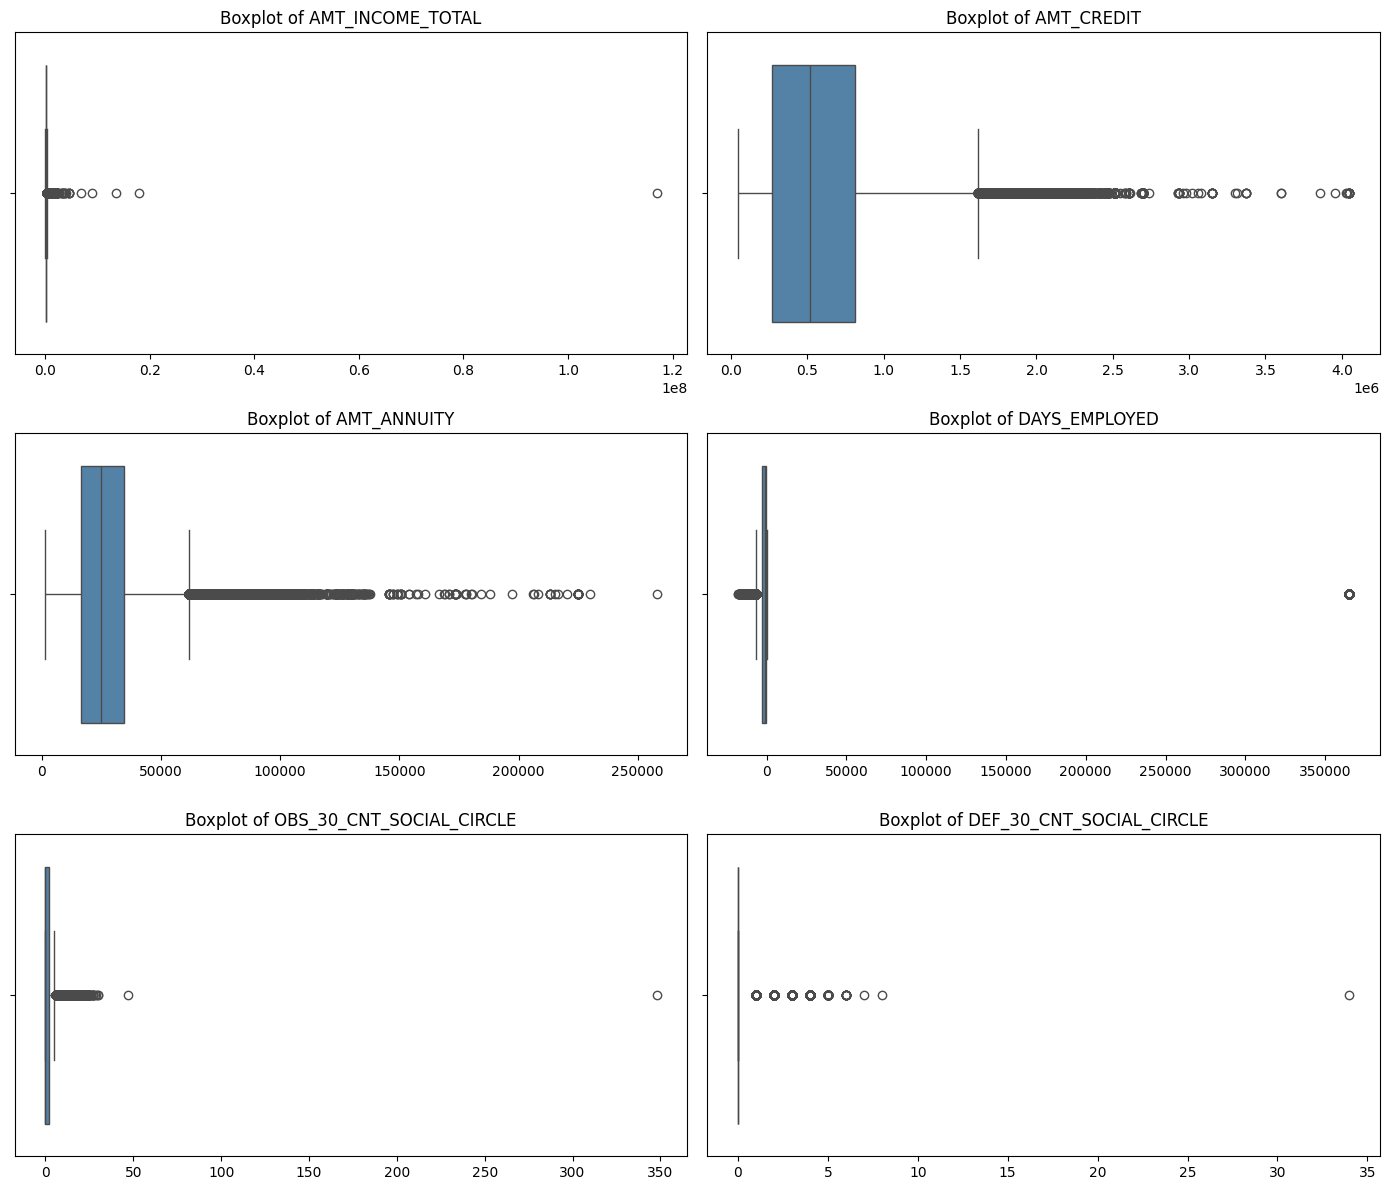

In [23]:
# Select key numerical features for outlier detection
outlier_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_EMPLOYED', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE'
]

# Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(outlier_features):
    # Boxplot
    sns.boxplot(x=df_app_train[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

- `AMT_INCOME_TOTAL` extreme outlier, **needs capping or log transformation**.
- `AMT_CREDIT` moderate spread with many high-value outliers, **needs capping**.
- `AMT_ANNUITY` mostly concentrated below 50k with outliers above 100k, **needs capping**.
- `DAYS_EMPLOYED` extreme outlier, **needs special handling**.
- `OBS_30_CNT_SOCIAL_CIRCLE` majority at 0 with one extreme outlier at ~350.
- `DEF_30_CNT_SOCIAL_CIRCLE` majority at 0 with sparse outliers up to ~34.

All features above require outlier treatment before modeling.
Capping for financial features and special encoding for `DAYS_EMPLOYED`.

---

## 4.2 Bivariate Analysis

This section examines the relationship between numerical features and the target variable (`TARGET`).
The goal is to identify which numerical features show the strongest separation between
default and non-default applicants.

The approach includes:
- **Comparing** distributions of each numerical feature between default and non-default groups
- **Evaluating** default rate across binned value ranges to identify high-risk segments

### 4.2.1 Distribution By Target (KDE Plot)

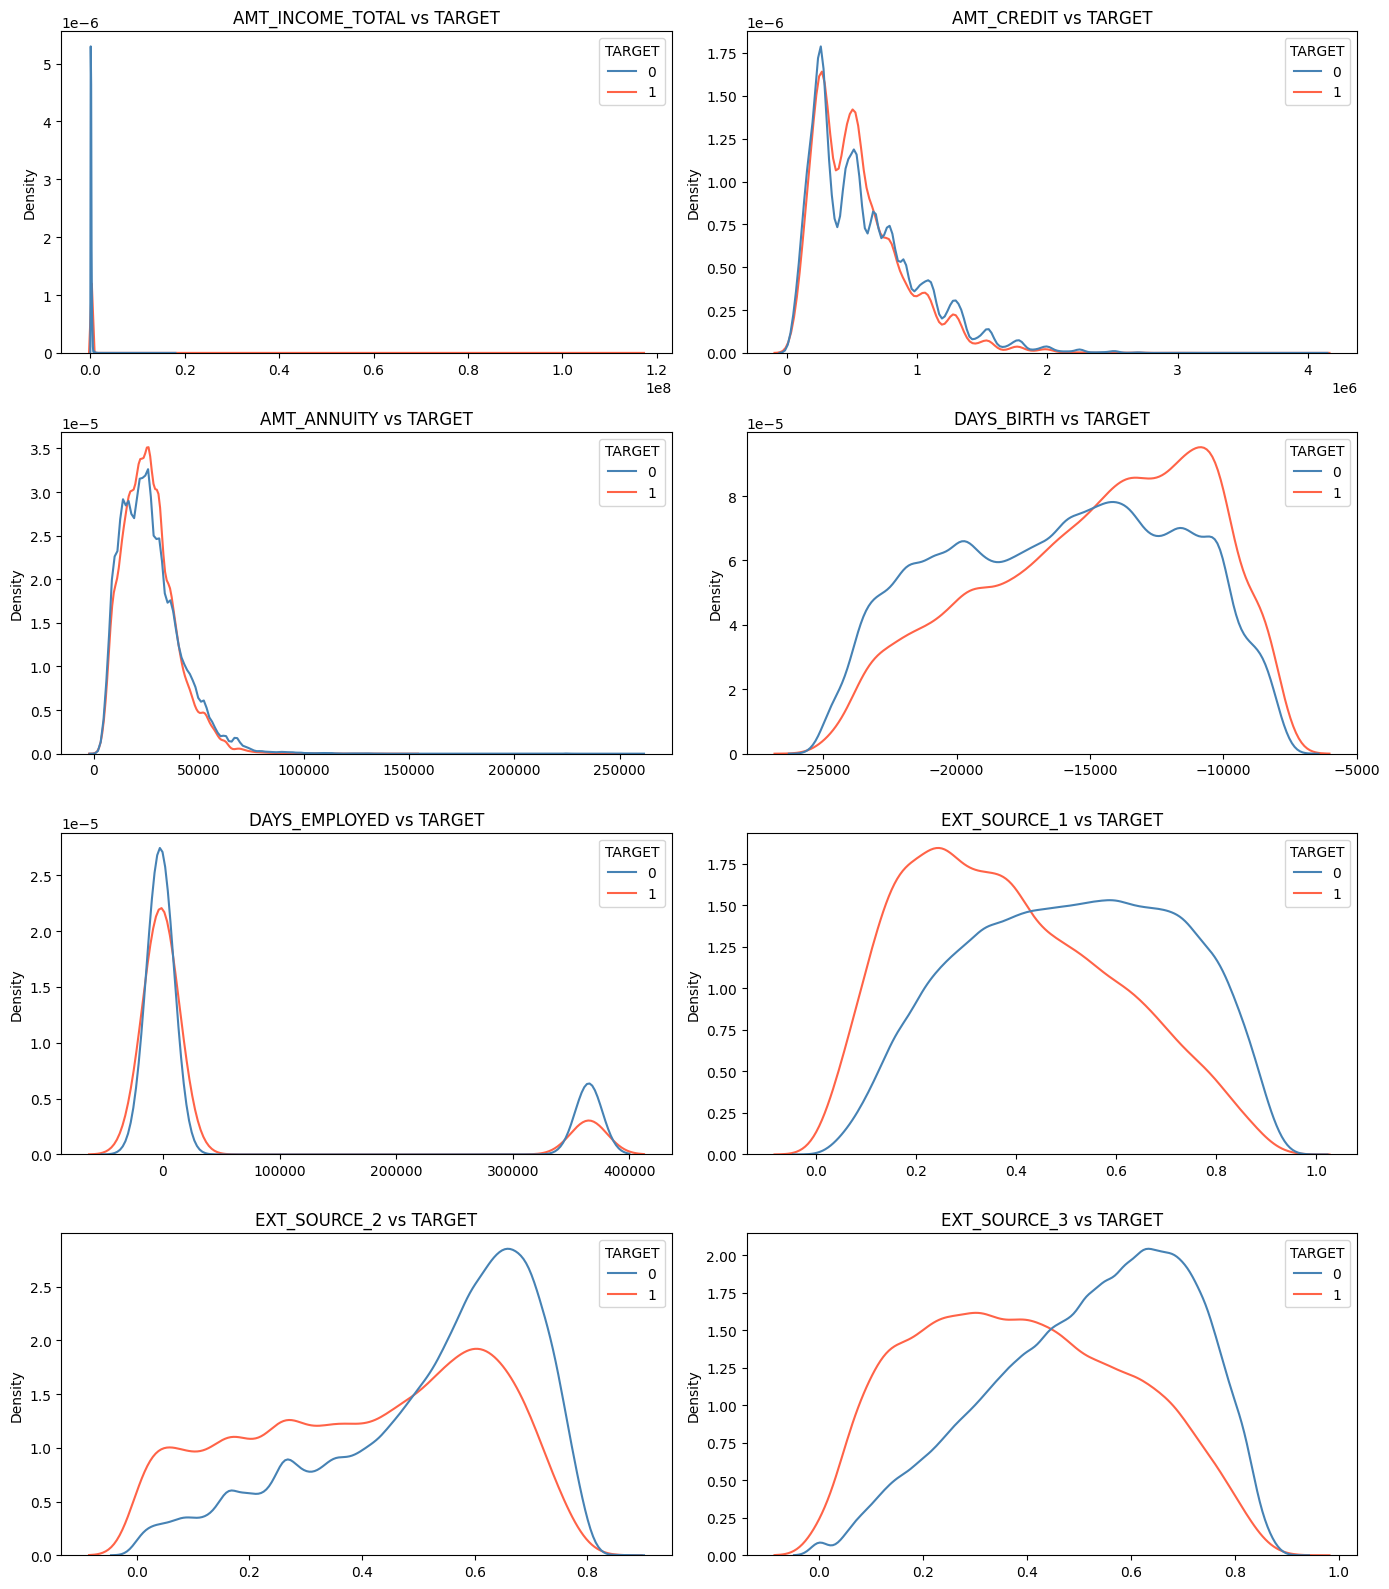

In [24]:
# Select key numerical features for bivariate analysis vs TARGET
num_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# Grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(num_features):
    # KDE plot per class, common_norm=False to handle class imbalance
    sns.kdeplot(
        data=df_app_train, x=col,
        hue='TARGET', common_norm=False,
        ax=axes[i], palette={0: 'steelblue', 1: 'tomato'}
    )
    axes[i].set_title(f'{col} vs TARGET')
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#### Key Findings

**AMT_INCOME_TOTAL**
Distribution is heavily compressed due to extreme outliers, both classes are barely distinguishable.
Confirms the need for capping or log transformation before further analysis.

**AMT_CREDIT**
Default tends to concentrate at lower-to-medium credit amounts while non-default spreads
toward higher credit values, suggesting applicants with smaller loans are at higher default risk.

**AMT_ANNUITY**
Both classes show very similar distributions, likely **low discriminative power** against TARGET.

**DAYS_BIRTH**
Clear separation between classes where default concentrates at less negative values
(younger applicants) while non-default spreads toward more negative values (older applicants).
**Younger age is associated with higher default risk.**

**DAYS_EMPLOYED**
Two distinct clusters visible, main cluster around 0 (employed) and a spike at ~365,243,
confirming the encoding anomaly. Requires special handling before modeling.

**EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3**
Clearest separation among all features where default consistently concentrates at **lower values**
and non-default at **higher values**. Confirms that `EXT_SOURCE` features are the
**most discriminative predictors** of TARGET.

---

### 4.2.2 Default Rate by Binned Feature

Numerical features are divided into bins to calculate the default rate per group.
This makes it easier to identify at which value range the default risk is highest.

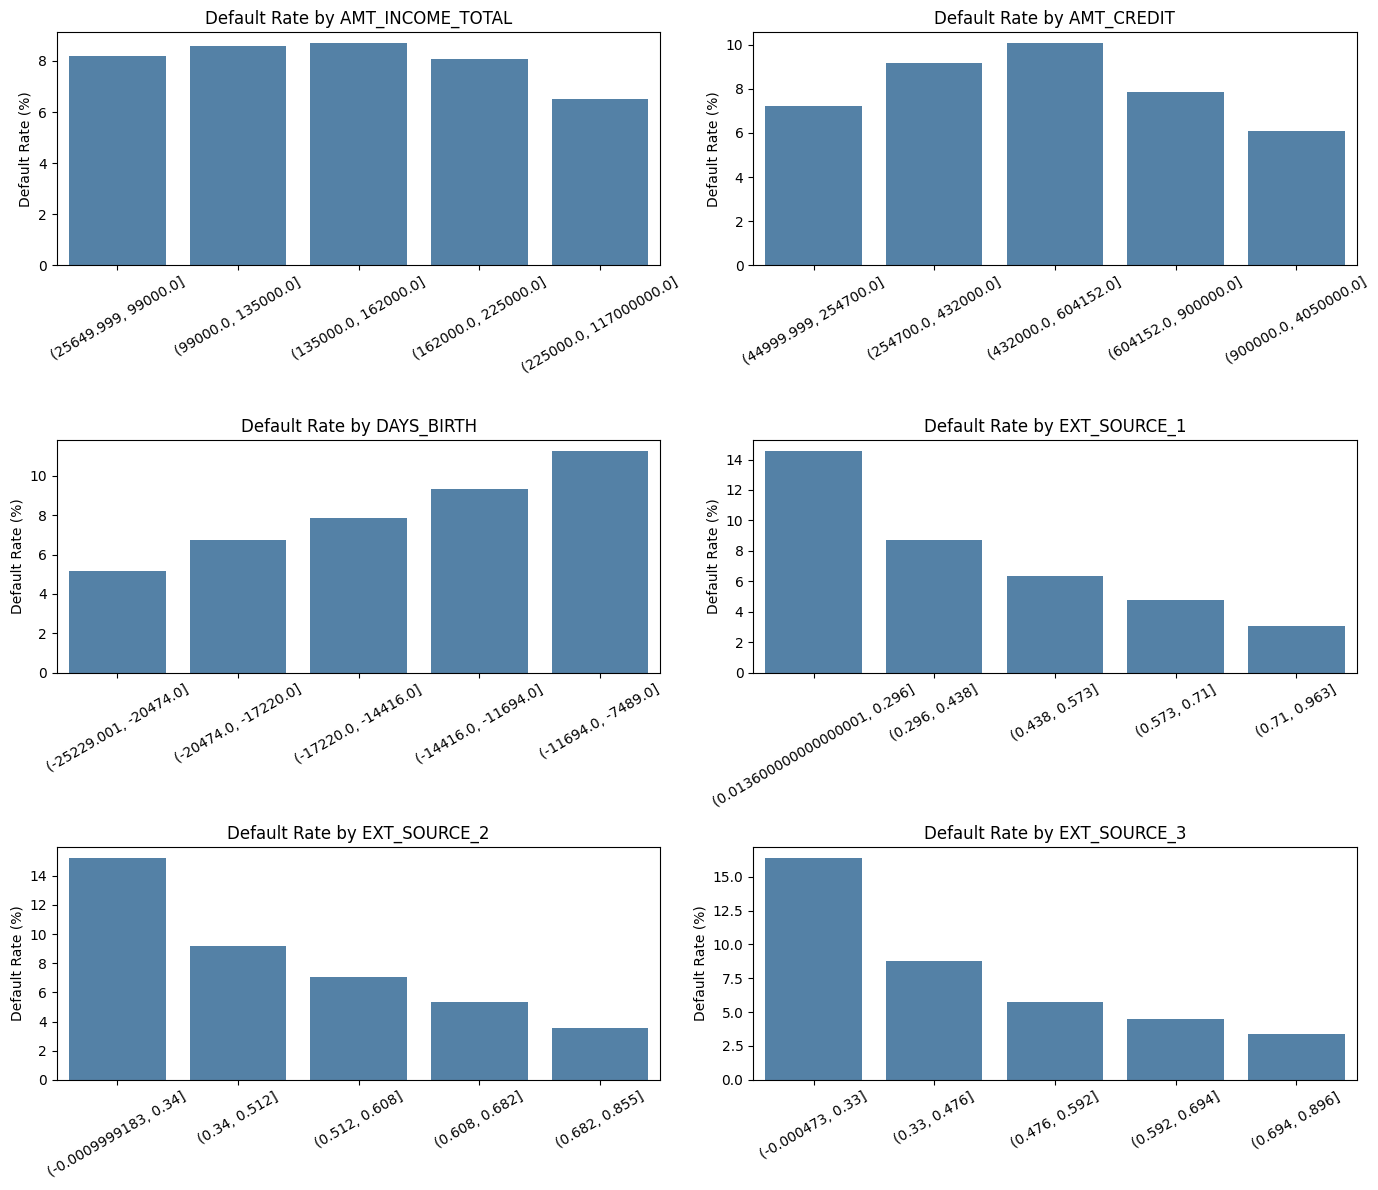

In [25]:
# Select key features for binned default rate analysis
bin_features = {
    'AMT_INCOME_TOTAL': 5,
    'AMT_CREDIT': 5,
    'DAYS_BIRTH': 5,
    'EXT_SOURCE_1': 5,
    'EXT_SOURCE_2': 5,
    'EXT_SOURCE_3': 5
}

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, (col, bins) in enumerate(bin_features.items()):
    temp = df_app_train.copy()
    temp[f'{col}_BIN'] = pd.qcut(temp[col], q=bins, duplicates='drop')
    default_rate = temp.groupby(f'{col}_BIN', observed=True)['TARGET'].mean() * 100

    sns.barplot(x=default_rate.index.astype(str), y=default_rate.values,
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Default Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### Key Findings

**AMT_INCOME_TOTAL**
Default rate relatively flat across all income bins (~8%), with slight decrease at the highest income group.
Income alone is not a strong discriminator of default risk.

**AMT_CREDIT**
Default rate peaks at mid-range credit (~432k to 604k) then drops at higher credit amounts,
suggesting applicants with very large loans are actually lower risk.

**DAYS_BIRTH**
Clear trend where younger applicants (less negative values) have significantly higher default rate (~11%),
while older applicants show lower risk (~5%). Confirms age as a meaningful predictor.

**EXT_SOURCE_1**
Strong decreasing trend from ~14% at lowest scores down to ~3% at highest scores.
Higher external score strongly associated with lower default risk.

**EXT_SOURCE_2**
Same pattern as EXT_SOURCE_1, default rate drops consistently from ~15% to ~4%
as the score increases. Strong predictive signal confirmed.

**EXT_SOURCE_3**
Strongest pattern among all three, default rate drops from ~16% at lowest scores
to ~3% at highest scores. **Most discriminative feature** in this analysis.

---

# 5. Categorical Features Analysis

## 5.1 Univariate Analysis

Univariate analysis for categorical features examines each feature independently
to understand its category distribution, frequency, and concentration.

The approach includes:
- **Describing** each feature through unique value counts, most frequent category, and its frequency percentage
- **Identifying** dominant categories, near-constant features, and rare categories that may need handling

### 5.1.1 Statistical Descriptive

In [26]:
# Select all categorical features
cat_features = df_app_train.select_dtypes(include='object').columns

# Build summary: unique values, most frequent category, and its frequency
cat_summary = pd.DataFrame({
    'Unique_Values': df_app_train[cat_features].nunique(),
    'Most_Frequent': df_app_train[cat_features].apply(lambda x: x.value_counts().index[0]),
    'Frequency': df_app_train[cat_features].apply(lambda x: x.value_counts().iloc[0]),
    # Frequency as percentage of non-missing rows
    'Frequency_%': df_app_train[cat_features].apply(
        lambda x: (x.value_counts().iloc[0] / x.count() * 100).round(2)
    )
})

cat_summary

,Unique_Values,Most_Frequent,Frequency,Frequency_%
NAME_CONTRACT_TYPE,2,Cash loans,278232,90.48
CODE_GENDER,3,F,202448,65.83
FLAG_OWN_CAR,2,N,202924,65.99
FLAG_OWN_REALTY,2,Y,213312,69.37
NAME_TYPE_SUITE,7,Unaccompanied,248526,81.16
NAME_INCOME_TYPE,8,Working,158774,51.63
NAME_EDUCATION_TYPE,5,Secondary / secondary special,218391,71.02
NAME_FAMILY_STATUS,6,Married,196432,63.88
NAME_HOUSING_TYPE,6,House / apartment,272868,88.73
OCCUPATION_TYPE,18,Laborers,55186,26.14


In [27]:
# Looking for Values from each Features
for col in df_app_train.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df_app_train[col].value_counts())


NAME_CONTRACT_TYPE:
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64

CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

FLAG_OWN_CAR:
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_REALTY:
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

NAME_TYPE_SUITE:
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271
Name: count, dtype: int64

NAME_INCOME_TYPE:
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

NAME_EDUCATION_TYPE:
NAME_EDUCATION_TYPE
Secondary / secondary special   

#### Key Findings

**Near-Constant Features — Consider Dropping**
- `HOUSETYPE_MODE` with 98.23% *block of flats*
- `EMERGENCYSTATE_MODE` with 98.56% *No*
- `FONDKAPREMONT_MODE` with 75.94% *reg oper account*, heavily dominated by one category

**High Cardinality**
- `ORGANIZATION_TYPE` has 58 unique categories including *XNA* (55,374 rows) that needs investigation, may need grouping or target encoding before modeling.
- `OCCUPATION_TYPE` has 18 categories, consider grouping rare categories.

**Rare Categories — Needs Handling**
- `CODE_GENDER` contains *XNA* with only 4 rows, replace with mode or drop.
- `NAME_FAMILY_STATUS` contains *Unknown* with only 2 rows, replace with mode.
- `NAME_INCOME_TYPE` contains *Maternity leave* (5), *Businessman* (10), *Student* (18) with very few records, consider grouping into a single category.

**Notable Distributions**
- `NAME_CONTRACT_TYPE` is 90.48% *Cash loans*, heavily imbalanced.
- `NAME_HOUSING_TYPE` is 88.73% *House/apartment*, low variation.
- `NAME_EDUCATION_TYPE` is 71.02% *Secondary/secondary special*, lower education dominates.

**Features for Further Analysis**
- `CODE_GENDER`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `OCCUPATION_TYPE` have
  sufficient variation to explore default rate differences across categories.
- `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE`, `WALLSMATERIAL_MODE` to check if default rate differs meaningfully across categories.
- `ORGANIZATION_TYPE` to explore default rate patterns despite high cardinality.
- `NAME_CONTRACT_TYPE` to confirm default rate difference between loan types.

---

### 5.1.2 Frequency Plot
Bar plots are used to visualize the frequency distribution of each categorical feature.
This helps identify dominant categories, class imbalance within features,
and rare categories that may need grouping before modeling.

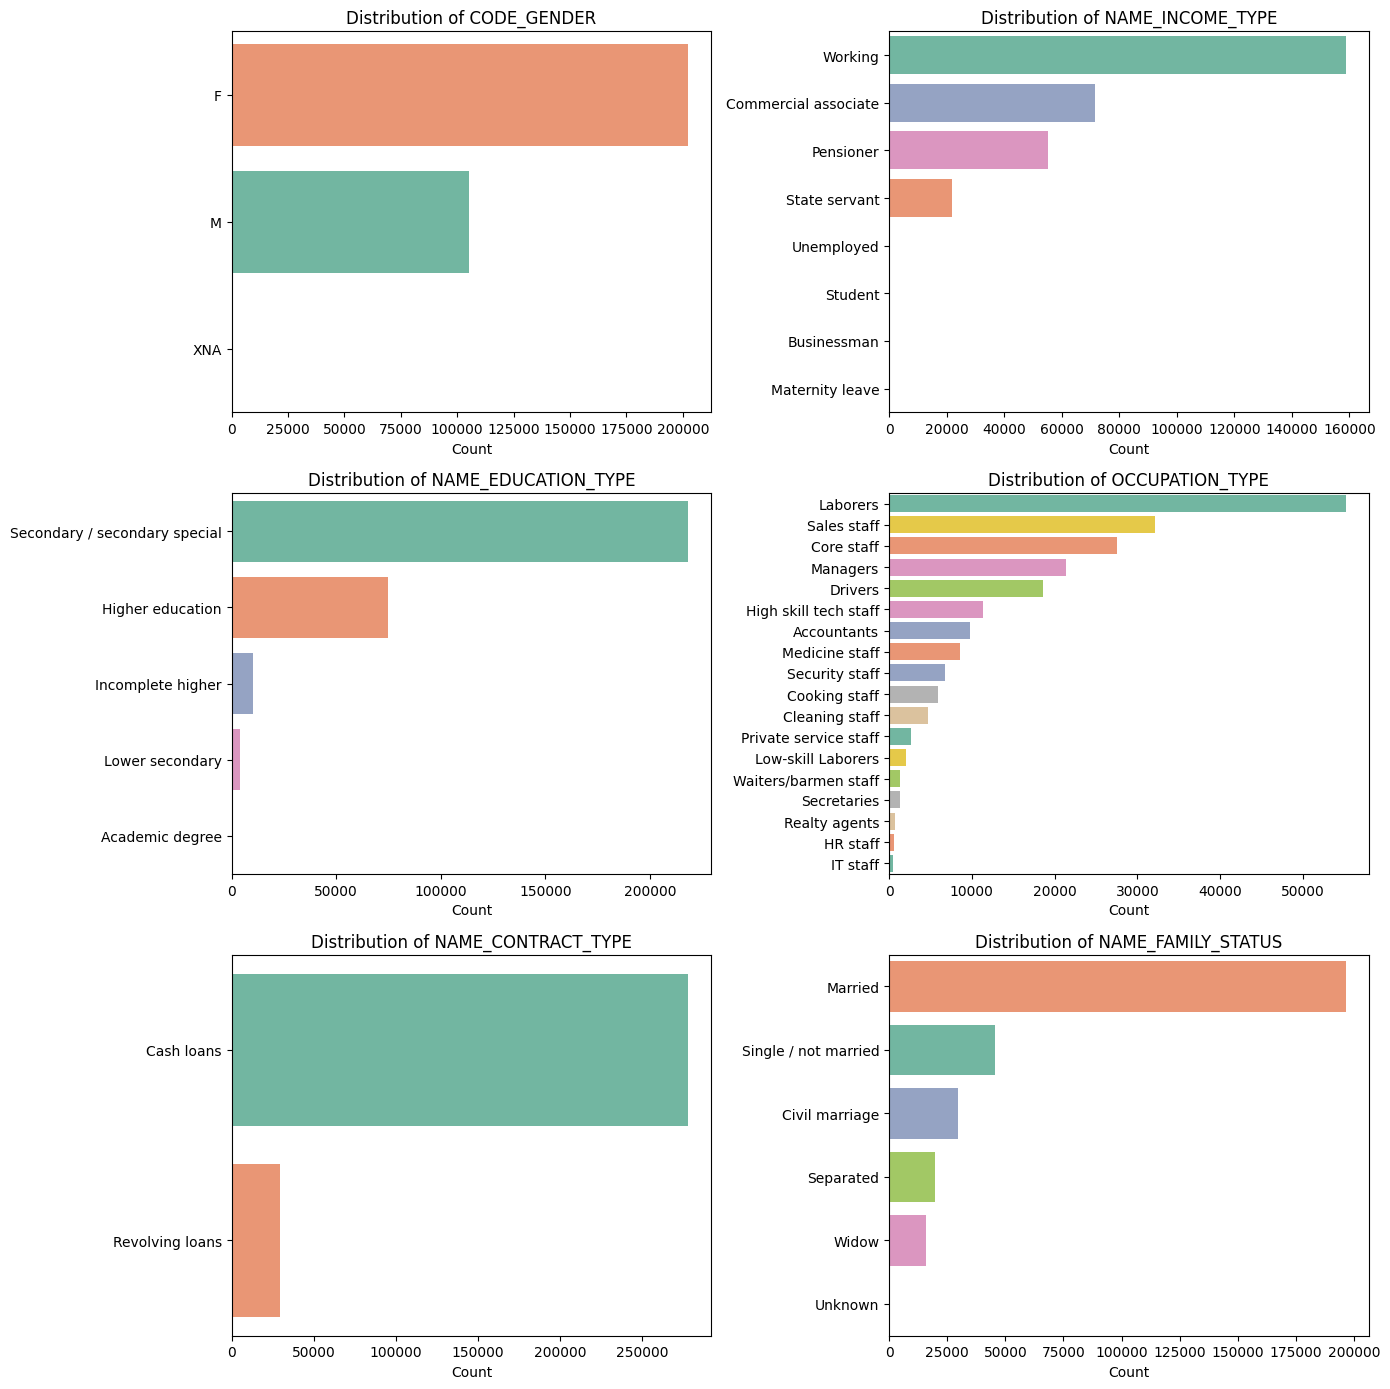

In [32]:
# Select categorical features with sufficient variation for analysis
cat_features = [
    'CODE_GENDER', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE',
    'NAME_CONTRACT_TYPE', 'NAME_FAMILY_STATUS'
]

# 2 Grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Sort bars by frequency
    order = df_app_train[col].value_counts().index
    # Horizontal bar plot
    sns.countplot(
        data=df_app_train, y=col,
        order=order, ax=axes[i],
        hue=col, palette='Set2', legend=False
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('Count')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

#### Key Findings

**CODE_GENDER**
Female applicants (F) dominate the dataset with ~202k records compared to male (~105k).
XNA is negligible with only 4 records, needs handling before modeling.

**NAME_INCOME_TYPE**
Working class dominates with ~159k records, followed by Commercial associate and Pensioner.
Maternity leave, Student, and Businessman have extremely few records, consider grouping.

**NAME_EDUCATION_TYPE**
Secondary/secondary special heavily dominates (~218k), while Academic degree has only 164 records.
Dataset is skewed toward lower education levels.

**OCCUPATION_TYPE**
Laborers are the most frequent (~55k), while IT staff, HR staff, and Realty agents
have very few records. Consider grouping rare occupations before modeling.

**NAME_CONTRACT_TYPE**
Cash loans dominate at ~278k vs Revolving loans at ~29k, heavily imbalanced.

**NAME_FAMILY_STATUS**
Married applicants dominate (~196k), while Unknown has only 2 records, replace with mode.

---

## 5.2 Bivariate Analysis

This section examines the relationship between categorical features and the target variable (`TARGET`).
The goal is to identify which categories carry the highest default risk.

The approach includes:
- **Evaluating** default rate differences across categories of each feature
- **Identifying** high-risk and low-risk groups within each categorical feature

### 5.2.1 Categorical Features Vs Target

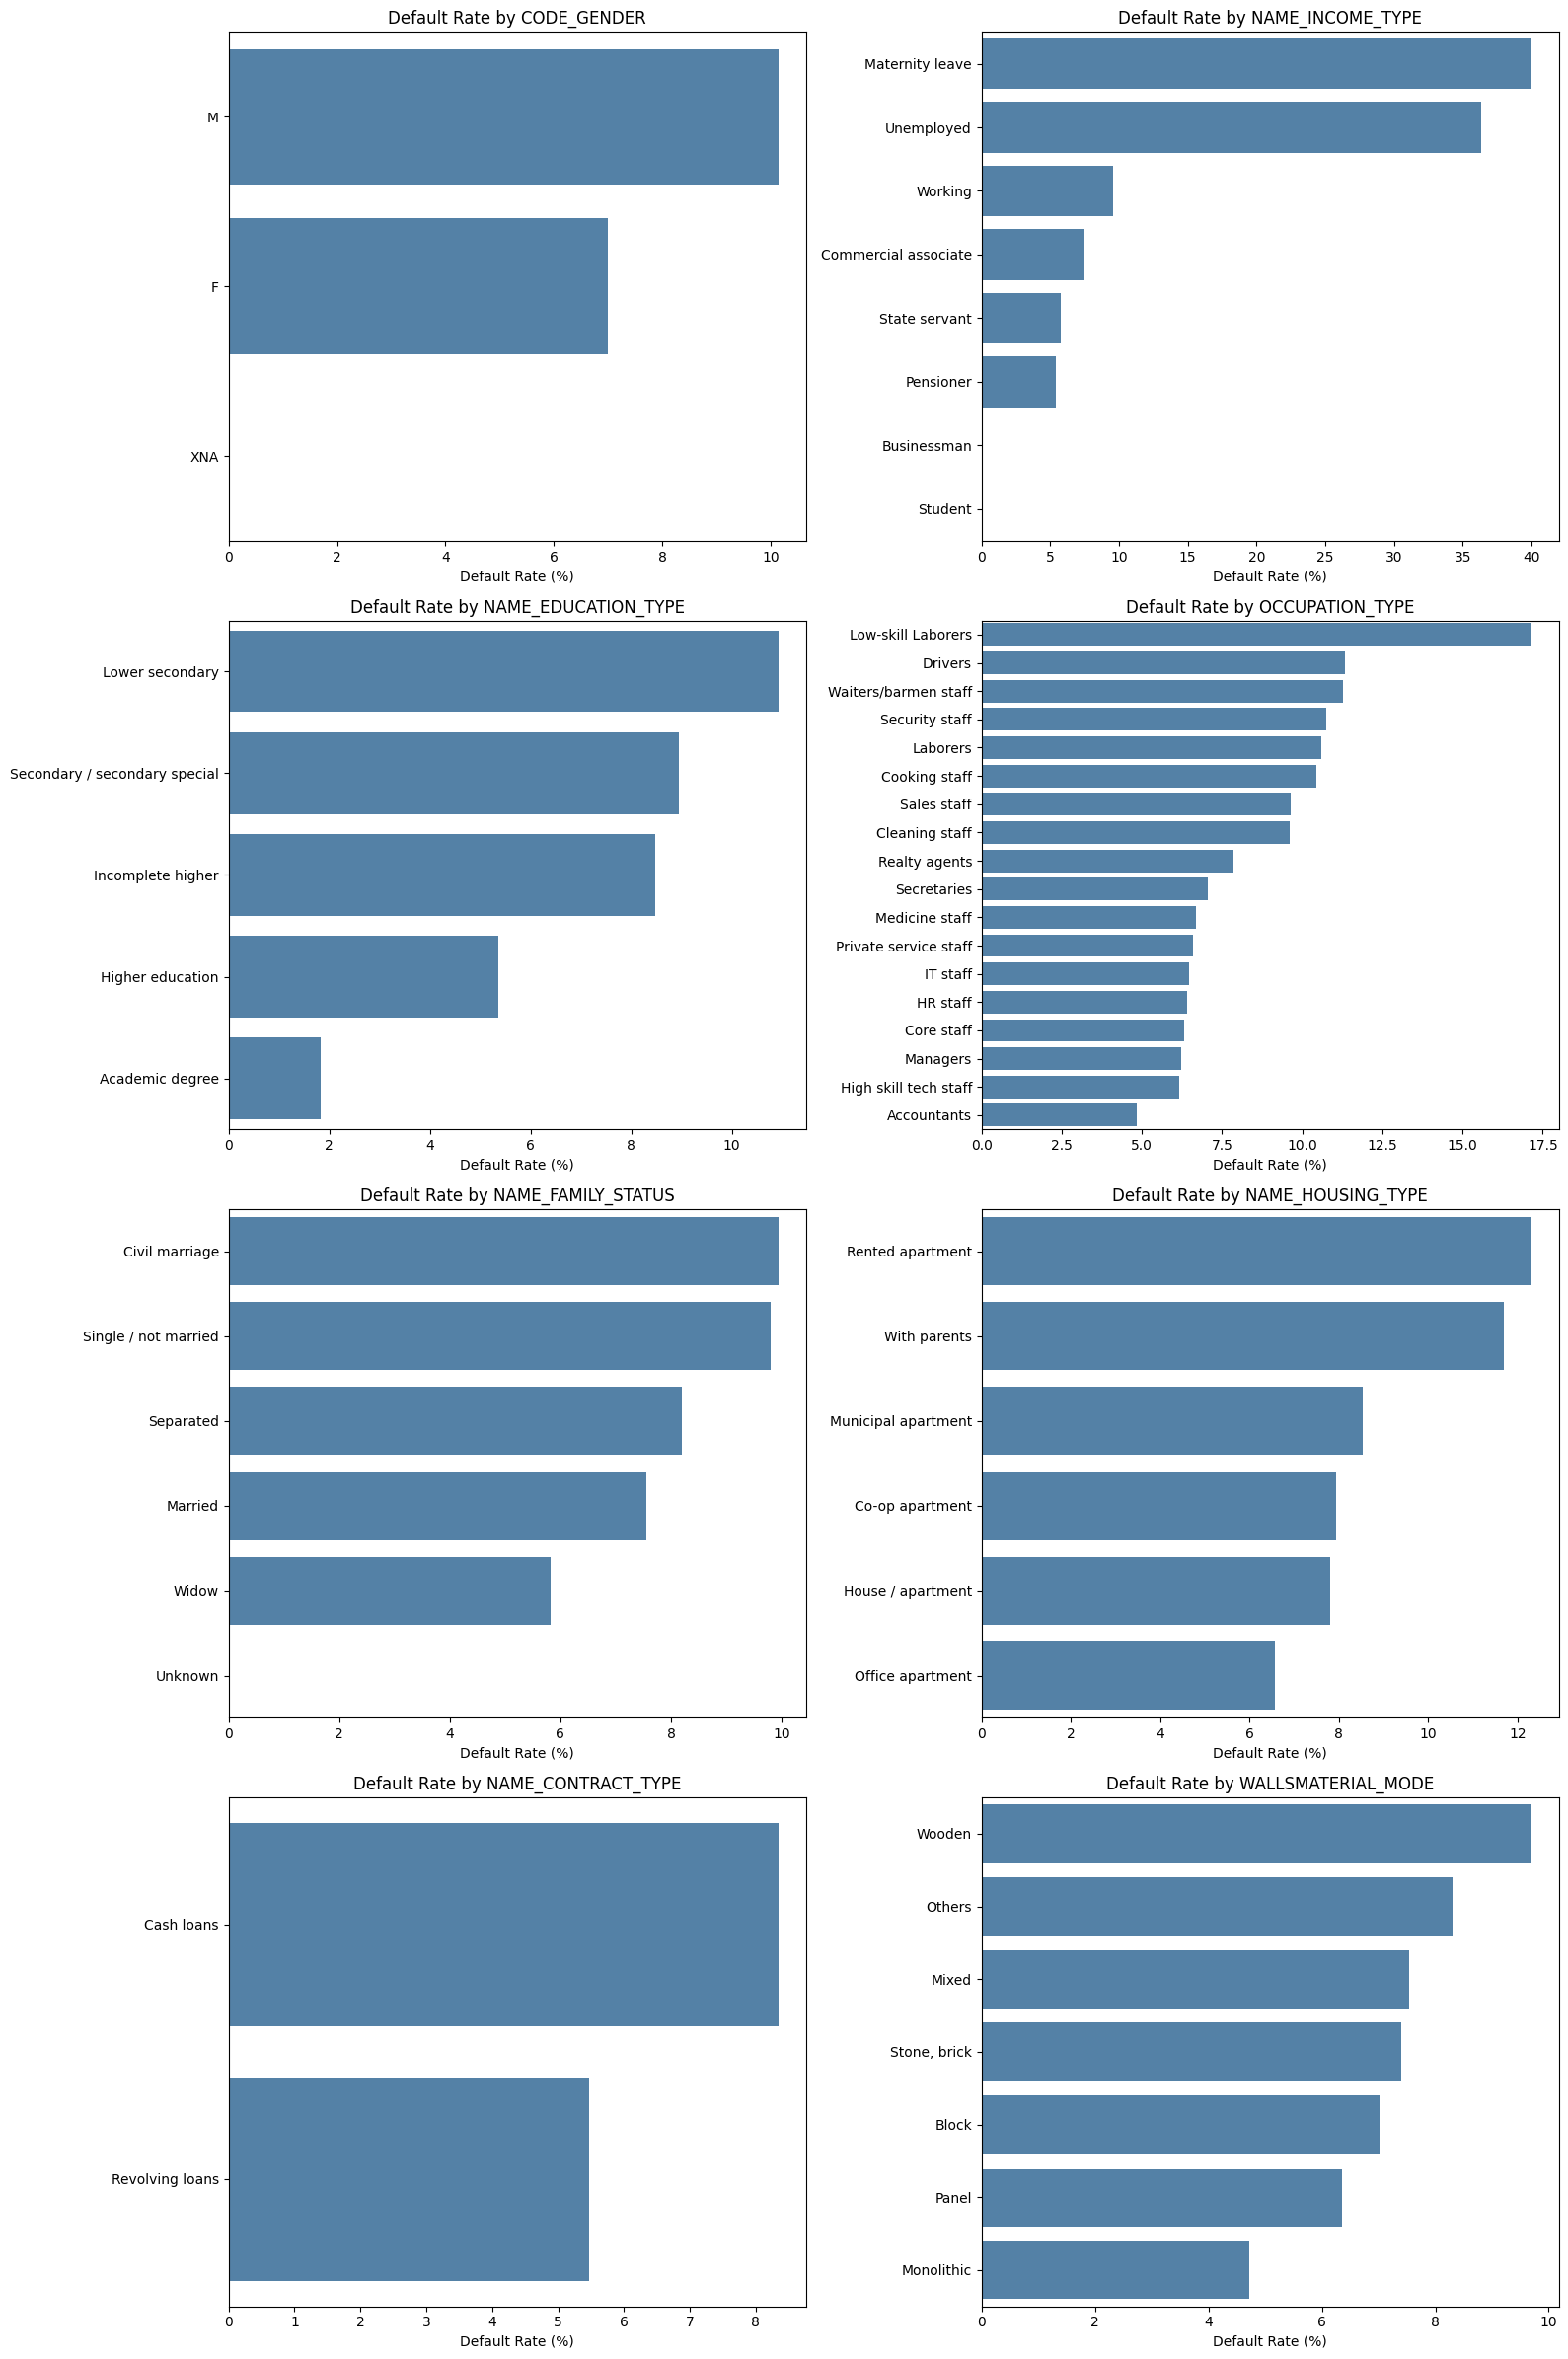

In [29]:
# Select categorical features for default rate analysis
cat_features = [
    'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'OCCUPATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'NAME_CONTRACT_TYPE', 'WALLSMATERIAL_MODE'
]

# Grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    # Default rate per category
    default_rate = df_app_train.groupby(col)['TARGET'].mean() * 100
    # Sort by default rate descending
    default_rate = default_rate.sort_values(ascending=False)

    sns.barplot(x=default_rate.values, y=default_rate.index,
                ax=axes[i], color='steelblue')
    axes[i].set_title(f'Default Rate by {col}')
    axes[i].set_xlabel('Default Rate (%)')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

#### Key Findings

**CODE_GENDER**
Male applicants have higher default rate (~10%) compared to female (~7%).
XNA shows near-zero default rate, needs to be handled before modeling.

**NAME_CONTRACT_TYPE**
Cash loans have higher default rate (~8%) compared to Revolving loans (~5%),
suggesting revolving loan applicants are relatively lower risk.

**NAME_INCOME_TYPE**
Maternity leave (~40%) and Unemployed (~37%) show extremely high default rates.
Pensioner and State servant are among the lowest risk groups.
Income type is a strong predictor of default risk.

**NAME_EDUCATION_TYPE**
Clear inverse relationship between education level and default risk.
Lower secondary has the highest default rate (~11%) while Academic degree has the lowest (~2%).

**OCCUPATION_TYPE**
Low-skill Laborers (~17%), Drivers and Waiters/Barmen staff (~13%) are highest risk.
Accountants and High-skill tech staff show the lowest risk (~4%).

**NAME_FAMILY_STATUS**
Civil marriage and Single applicants show the highest default rate (~10%).
Widow shows the lowest risk (~5%), suggesting age/stability factor.

**NAME_HOUSING_TYPE**
Rented apartment (~12%) and With parents (~11%) show higher default risk,
while Office apartment has the lowest (~6%).
Housing stability appears correlated with repayment behavior.

**WALLSMATERIAL_MODE**
Wooden (~10%) and Others (~9%) show higher default rates while
Monolithic shows the lowest (~4%). Moderate variation worth retaining.

---

# 6. Correlation Analysis

This section examines the linear relationship between numerical features and the target variable,
as well as multicollinearity between features. Results are used to identify the most relevant
features for modeling and detect redundant features that may need to be dropped.

The approach includes:
- **Heatmap** to visualize pairwise correlation between key numerical features
- **Point-Biserial Correlation** to rank feature correlation directly against TARGET

## 6.1 Heatmap


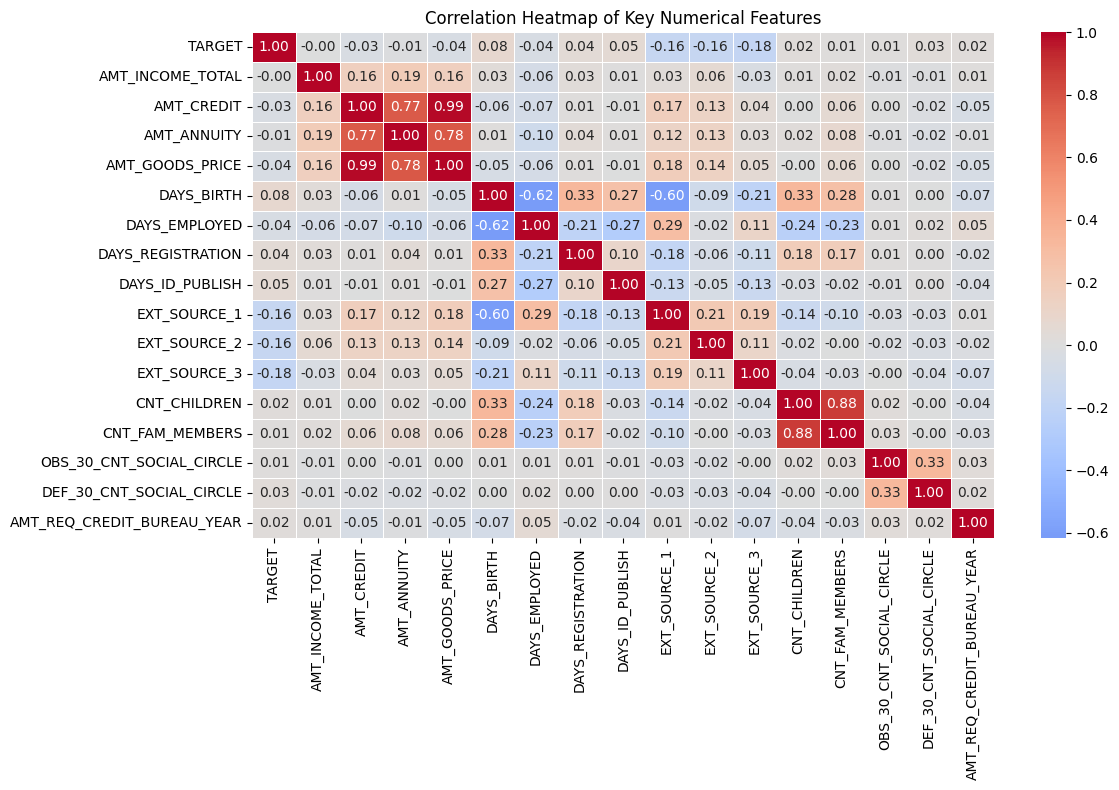

In [37]:
# Select key numerical features for correlation analysis
corr_features = [
    'TARGET',
    # Financial features
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    # Days features
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    # External credit scores — most discriminative
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    # Demographic
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    # Social circle
    'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
    # Credit bureau enquiries
    'AMT_REQ_CREDIT_BUREAU_YEAR'
]

# Compute correlation matrix
corr_matrix = df_app_train[corr_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Key Numerical Features')
plt.tight_layout()
plt.show()

#### Key Findings

**EXT_SOURCE features are the strongest predictors of TARGET**
`EXT_SOURCE_3` (-0.18), `EXT_SOURCE_2` (-0.16), and `EXT_SOURCE_1` (-0.16) show
the highest correlation with TARGET among all features, confirming findings from bivariate analysis.
Higher external score = lower default risk.

**DAYS_BIRTH has meaningful negative correlation with TARGET (-0.08)**
Older applicants (more negative DAYS_BIRTH) tend to have lower default risk,
consistent with findings in 4.2.1 and 4.2.2.

**High multicollinearity detected among financial features**
`AMT_CREDIT` and `AMT_GOODS_PRICE` are almost perfectly correlated (0.99),
and `AMT_ANNUITY` is also highly correlated with both (0.77-0.78).
Consider dropping one of these groups to reduce redundancy during feature selection.

**DAYS_BIRTH and DAYS_EMPLOYED are highly correlated (-0.62)**
Older applicants tend to have longer employment history, which makes sense contextually.
Both should be retained but their shared information should be considered during modeling.

**CNT_CHILDREN and CNT_FAM_MEMBERS are highly correlated (0.88)**
Both measure family size from different angles. Consider retaining only one,
or engineering a derived feature such as `CNT_NON_CHILDREN = CNT_FAM_MEMBERS - CNT_CHILDREN`.

**OBS and DEF social circle features are moderately correlated (0.33)**
Expected since more observed defaults in social circle naturally correlates
with the number of observations. Both can be retained.

**AMT_INCOME_TOTAL shows near-zero correlation with TARGET (-0.00)**
Confirms finding from 4.2.2 that income alone is not a strong predictor of default risk.

## 6.2 Point-Biserial Correlation

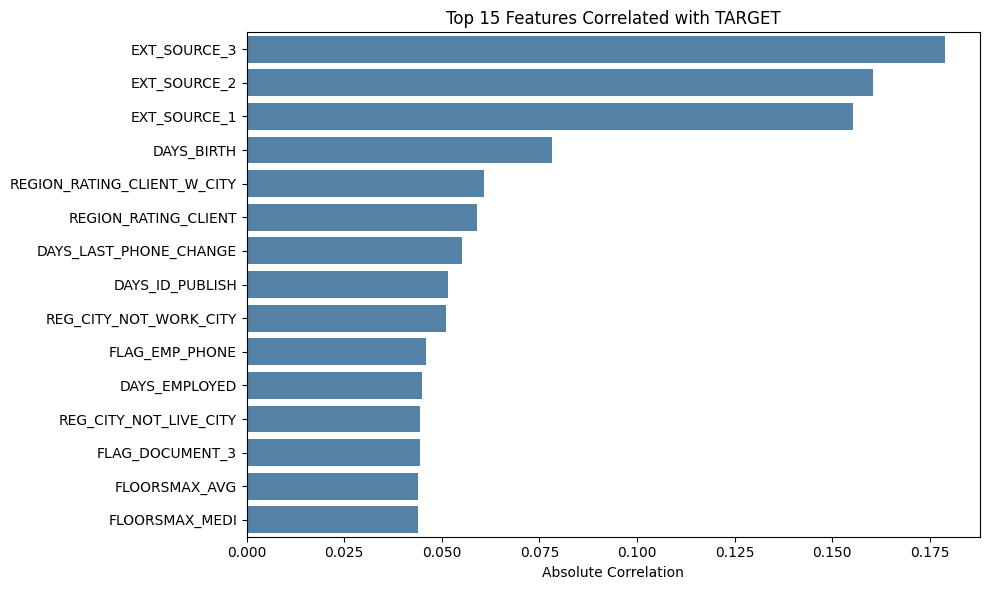

In [36]:
# Compute correlation of all numerical features against TARGET
target_corr = (
    df_app_train.select_dtypes(include='number')
    .corr()['TARGET']
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, color='steelblue')
plt.title('Top 15 Features Correlated with TARGET')
plt.xlabel('Absolute Correlation')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Key Findings

**EXT_SOURCE dominates as top predictors**
`EXT_SOURCE_3` (0.18), `EXT_SOURCE_2` (0.16), and `EXT_SOURCE_1` (0.16) are
the three strongest features correlated with TARGET, confirming all previous analyses.

**DAYS_BIRTH is the strongest non-EXT_SOURCE predictor (0.08)**
Age remains a meaningful predictor, consistent with findings in 4.2.1 and 4.2.2.

**Region rating features appear in top 10**
`REGION_RATING_CLIENT_W_CITY` and `REGION_RATING_CLIENT` both show moderate correlation (~0.06),
suggesting the region where a client lives carries some default risk signal.

**Days features cluster in mid-range**
`DAYS_LAST_PHONE_CHANGE`, `DAYS_ID_PUBLISH`, and `DAYS_EMPLOYED` all appear in top 15,
confirming that temporal features are collectively informative despite individually moderate correlations.

**Address mismatch flags show signal**
`REG_CITY_NOT_WORK_CITY` and `REG_CITY_NOT_LIVE_CITY` appear in top 15,
suggesting applicants whose registered address does not match work or living address
may carry higher default risk.

**Overall correlations are low across all features**
Even the strongest feature (`EXT_SOURCE_3`) has absolute correlation of only ~0.18,
indicating no single feature is strongly predictive on its own.
**This confirms the need for a combination of features in modeling.**

---

# 7. Overall Insights & Recommendations

## Key Predictors Identified
- `EXT_SOURCE_1/2/3` are the strongest predictors of default risk across all analyses
- `DAYS_BIRTH` confirms younger applicants carry higher default risk
- `NAME_INCOME_TYPE` and `OCCUPATION_TYPE` show strong default rate differences across categories
- `REGION_RATING_CLIENT` and address mismatch flags carry moderate but meaningful signal

## Data Quality Issues to Address
- `DAYS_EMPLOYED` value of 365,243 is an encoding error, requires special handling
- `CODE_GENDER` XNA (4 rows) and `NAME_FAMILY_STATUS` Unknown (2 rows) need to be replaced with mode
- `NAME_INCOME_TYPE` rare categories (Maternity leave, Student, Businessman) should be grouped
- `AMT_INCOME_TOTAL` has extreme outlier at 117,000,000, needs capping

## Feature Engineering Recommendations
- Convert `DAYS_BIRTH`, `DAYS_EMPLOYED` to absolute values or age in years
- Derive `HAS_CAR` flag from `FLAG_OWN_CAR` as domain-aware imputation for `OWN_CAR_AGE`
- Derive `CNT_NON_CHILDREN = CNT_FAM_MEMBERS - CNT_CHILDREN` to reduce redundancy
- Consider grouping rare categories in `OCCUPATION_TYPE` and `ORGANIZATION_TYPE`

## Feature Selection Recommendations
- **Drop**: `FLAG_MOBIL`, `FLAG_CONT_MOBILE` (near-constant), `HOUSETYPE_MODE`, `EMERGENCYSTATE_MODE` (near-constant)
- **Drop or consolidate**: `AMT_GOODS_PRICE` (0.99 corr with `AMT_CREDIT`), `CNT_FAM_MEMBERS` (0.88 corr with `CNT_CHILDREN`)
- **Retain only `_AVG`** per building property group, drop `_MODE` and `_MEDI` variants
- **Retain `_MISSING` indicators** for features with high missing rates as they carry predictive signal

## Modeling Considerations
- Dataset is heavily imbalanced (8% default), requires oversampling, undersampling, or class weighting
- No single feature is strongly predictive on its own (max correlation ~0.18), combination of features is essential
- Tree-based models (XGBoost, LightGBM) may handle multicollinearity and missing values better than linear models


---

In [40]:
# import json

# with open('EDA_application_train.ipynb', 'r', encoding='utf-8') as f:
#     nb = json.load(f)

# for i, cell in enumerate(nb['cells']):
#     if cell['cell_type'] == 'markdown':
#         print(f"--- Cell {i} ---")
#         print(''.join(cell['source']))
#         print()